In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [63]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

In [64]:
diz = {
     0: 'Human',
     1: 'DeepSeek',
     2: 'Grok',   
     3: 'Claude',
     4: 'Gemini',
     5: 'ChatGPT',
}

In [65]:
print('Train')
print(train.shape)
print('Test')
print(test.shape)

Train
(2400, 2)
Test
(600, 2)


In [66]:
train.describe(include='object') # all texts are unique

,TEXT
count,2400
unique,2400
top,"Dear state senator, There should be a change i..."
freq,1


In [67]:
train['LABEL'].value_counts()
# it is an unbalanced dataset
# Since the metric is f1-macro, I need to give equal importance to all of them

LABEL
0    1520
5     320
4     240
2     160
1      80
3      80
Name: count, dtype: int64

In [68]:
# manually display some content that is not human written
train[train['LABEL'] != 0]

,TEXT,LABEL
1,A star's life cycle begins in a nebula and pro...,1
3,Biodiversity loss accelerates at unprecedented...,3
5,Year-round research in Antarctic bases is cruc...,1
7,Exploring the psychology of creativity examine...,5
10,"The Industrial Revolution, which began in the ...",2
...,...,...
2394,"Mechanical, and thermal properties of material...",5
2395,The study of biotechnology involves the use of...,5
2396,The Maya's advanced astronomical knowledge was...,1
2398,The delicate art of origami transforms a flat ...,1


In [69]:
train['len'] = train['TEXT'].apply(str.__len__)

In [70]:
train.groupby('LABEL').mean(numeric_only=True)

,len
LABEL,
0,2510.598684
1,560.025000
2,414.468750
3,3358.687500
4,2818.662500
5,1485.243750


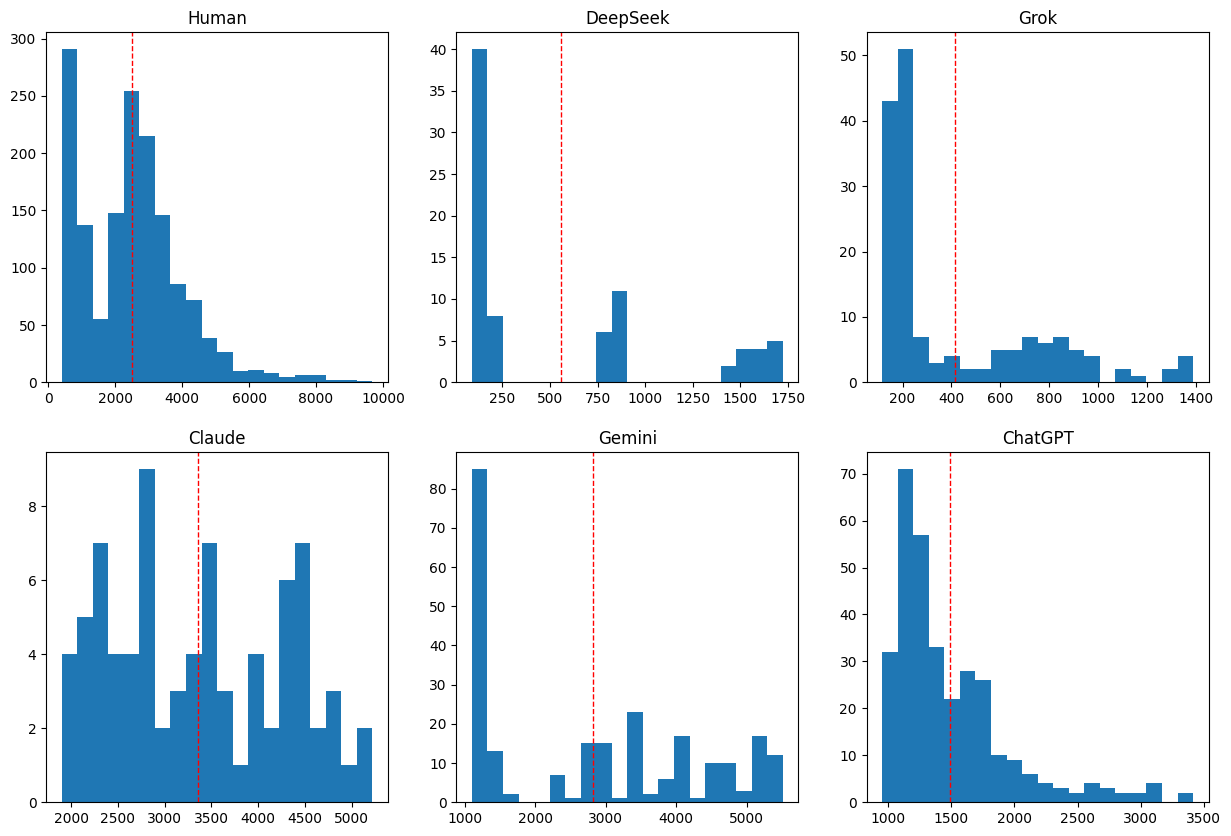

In [71]:
fig, ax = plt.subplots(2,3, figsize=(15, 10))
for i in range(6):
    ax[i//3][i%3].hist(train[train['LABEL'] == i]['len'], bins=20)
    # including mean value
    ax[i//3][i%3].axvline(train[train['LABEL'] == i]['len'].mean(), color='red', linestyle='dashed', linewidth=1)
    ax[i//3][i%3].set_title(diz[i])

In [ ]:
def sentence_metrics(text):
    sentences = [s.strip() for s in re.split(r'[.!?]+', text) if len(s.strip()) > 0]
    if not sentences:
        return 0, 0, 0
    
    words_per_sentence = [len(s.split()) for s in sentences]
    
    num_sentences = len(sentences)
    avg_words = np.mean(words_per_sentence)
    std_words = np.std(words_per_sentence)
    
    return num_sentences, avg_words, std_words

# humans often alternate long sentences with shorter ones... (I hope so)
sentence_metrics(train['TEXT'][0]), train['LABEL'][0]

((31, np.float64(16.870967741935484), np.float64(7.079010025027744)),
 np.int64(0))

In [ ]:
train['TEXT_str'] = train['TEXT'].astype(str) 
train['len'] = train['TEXT_str'].apply(len)
train['words_list'] = train['TEXT_str'].str.split()
train['num_words'] = train['words_list'].apply(lambda x: len(x))
# avoiding to explode something in case of missing text
train['len_safe'] = train['len'].replace(0, 1)
train['words_safe'] = train['num_words'].replace(0, 1)

# Punctuation...
punctuation_chars = {
    'periods': '.', 'commas': ',', 'dashes': '-', 
    'question': '?', 'exclamation': '!', 'semicolon': ';', 'colon': ':',
    'spaces': ' ', 'newlines': '\n', 'asterisks': '*'
}

for name, char in punctuation_chars.items():
    train[name] = train['TEXT_str'].apply(lambda x: x.count(char))
    train[f'{name}_per_len'] = train[name] / train['len_safe']

# mixed case like parenthesis and quotes
train['parenthesis'] = train['TEXT_str'].apply(lambda x: x.count('(') + x.count(')'))
train['parenthesis_per_len'] = train['parenthesis'] / train['len_safe']

train['quotes'] = train['TEXT_str'].apply(lambda x: x.count('"') + x.count("'"))
train['quotes_per_len'] = train['quotes'] / train['len_safe']

# uppercase and digits
train['uppercase'] = train['TEXT_str'].apply(lambda x: len(re.findall(r'[A-Z]', x)))
train['uppercase_per_len'] = train['uppercase'] / train['len_safe']

train['digits'] = train['TEXT_str'].apply(lambda x: len(re.findall(r'\d', x)))
train['digits_per_len'] = train['digits'] / train['len_safe']

# unique words
train['unique_words'] = train['words_list'].apply(lambda x: len(set(x)) if isinstance(x, list) else 0)
train['unique_words_per_words'] = train['unique_words'] / train['words_safe']

train['avg_word_length'] = train['words_list'].apply(
    lambda x: np.mean([len(w) for w in x]) if isinstance(x, list) and len(x) > 0 else 0
)

# enumerations
train['enumeration_num'] = train['TEXT_str'].apply(lambda x: len(re.findall(r'\d+\.', x)))
train['enumeration_num_per_len'] = train['enumeration_num'] / train['len_safe']

metrics = train['TEXT_str'].apply(sentence_metrics)
train['num_sentences'] = [m[0] for m in metrics]
train['sentences_per_len'] = train['num_sentences'] / train['len_safe']
train['avg_words_per_sentence'] = [m[1] for m in metrics]
train['std_sentence_length'] = [m[2] for m in metrics]

# Cleaning
train = train.drop(columns=['TEXT_str', 'words_list', 'len_safe', 'words_safe'])


cols_to_show = [c for c in train.columns if '_per_' in c or c == 'avg_word_length'] + ['std_sentence_length']
print(train.groupby('LABEL')[cols_to_show].mean())

       periods_per_len  commas_per_len  dashes_per_len  question_per_len  \
LABEL                                                                      
0             0.011318        0.007960        0.000882          0.000642   
1             0.006866        0.009218        0.001693          0.000000   
2             0.005742        0.011676        0.001533          0.000000   
3             0.023647        0.003640        0.001422          0.000000   
4             0.006833        0.008042        0.001351          0.000000   
5             0.006643        0.020032        0.001466          0.000000   

       exclamation_per_len  semicolon_per_len  colon_per_len  spaces_per_len  \
LABEL                                                                          
0                 0.000515           0.000109       0.000198        0.179139   
1                 0.000000           0.000056       0.000054        0.139404   
2                 0.000000           0.000070       0.000009        0.1